In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec
import matplotlib.colors as colors


import os


import seaborn as sns


# For venn diagram
from matplotlib_venn import venn3, venn2
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm, cost_based


## Load RNA cell Barcodes from RNA-only modality CR analysis

In [3]:
entropy_all_file = os.path.join(entropy_dir, 'calculated_barcode_entropy_wDNAdebrisflag_df.tsv')
entropy_df = pd.read_csv(entropy_all_file, sep=',', index_col=0)
entropy_df['atac_bc'] = entropy_df.index.str.split('-').str[0]
print(entropy_df.shape) 
entropy_df.head(2)

(33287, 8)


,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,CAGGTTACAGCCTAAA
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,GAACAATGTCGGTTAT


In [ ]:
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_barcodes'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])
frag['frag_length'] = frag['end'] - frag['start']

total_frag_per_bc = frag.groupby('atac_barcodes').size()
entropy_df['total_fragments'] = entropy_df.index.map(total_frag_per_bc)

In [25]:
entropy_df.head(2)

,Entropy,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,DNA_debris,atac_bc,total_fragments
CAGGTTACAGCCTAAA-1,0.005184,2.345061,28,1.782331,0.168245,0.999594,NO,CAGGTTACAGCCTAAA,537
GAACAATGTCGGTTAT-1,0.203897,0.735687,449,0.185787,0.830450,0.968089,NO,GAACAATGTCGGTTAT,4841


In [ ]:
# Load union set cells 
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'
Union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
Union_cell_info_file = os.path.join(Union_cell_subdir, 'Union_cell_3set_all_info.tsv')
union_cell_info = pd.read_csv(Union_cell_info_file, sep='\t', index_col=0)
union_cell_info.head(2)


,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac
atac_bc,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common


# Venn comparison

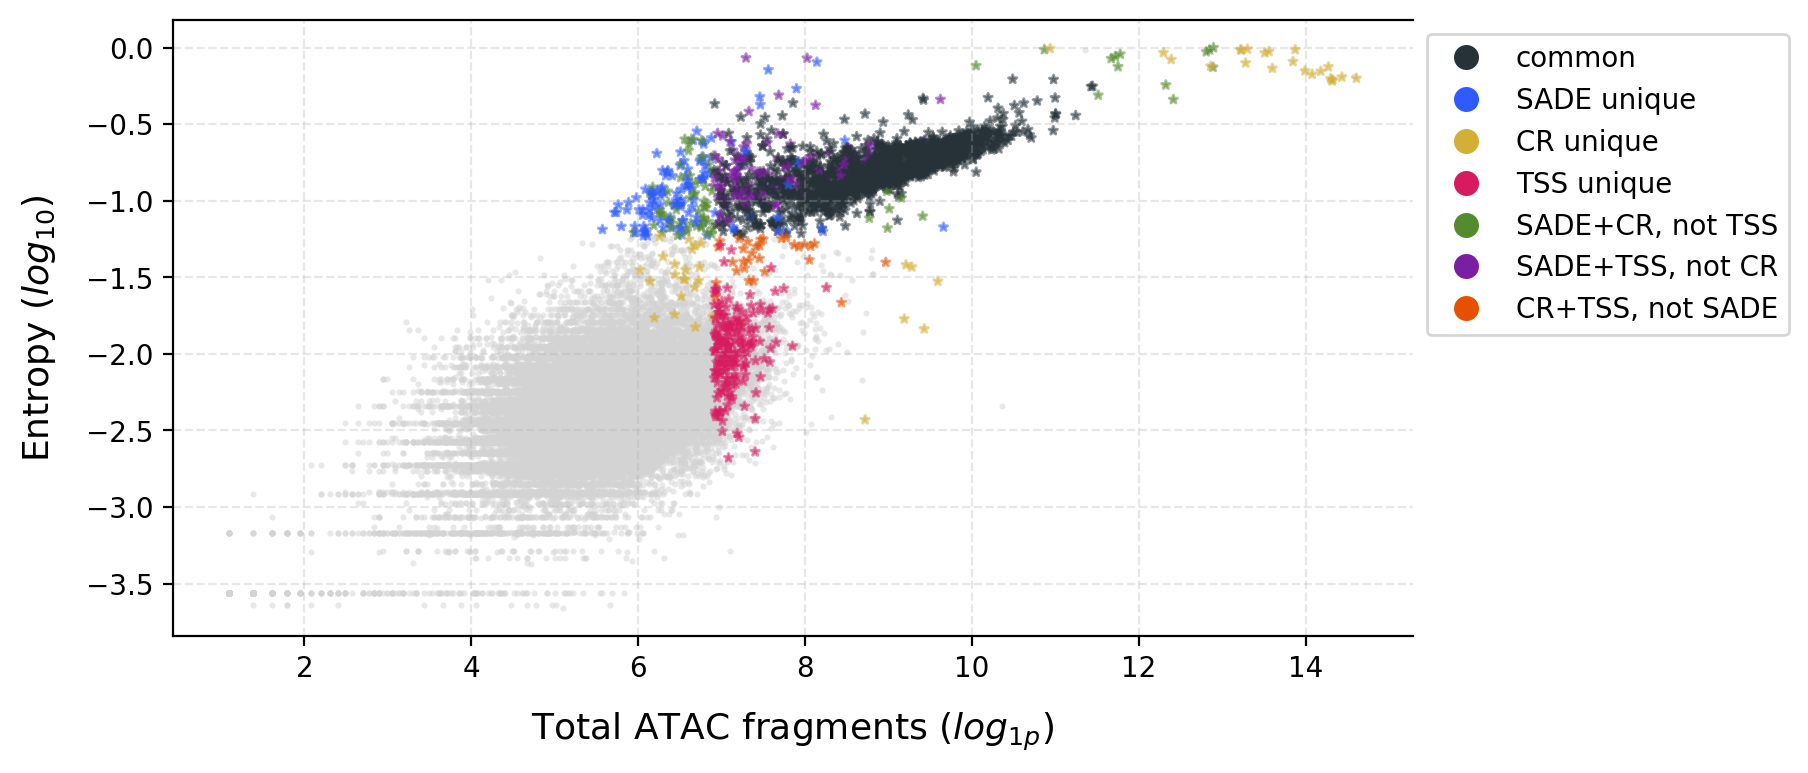

In [165]:
fig, ax = plt.subplots( figsize=(8, 4) )

colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]
colors_map = dict(zip(unique_categories, colors_list))                  
labels_map = dict(zip(unique_categories, unique_categories))

# droplets not in any of the 3 sets are colored in light gray
not_in_any_set = ~entropy_df['atac_bc'].isin(union_cell_info.index)
ax.scatter( np.log1p(entropy_df.loc[not_in_any_set, 'total_fragments']), 
            np.log10(entropy_df.loc[not_in_any_set, 'Entropy']), 
            c='lightgray',
            marker='o', 
            s=5,
            alpha=0.5,
            lw=0,)
# Now the droplets in the union set are colored by their category 
ax.scatter( np.log1p(union_cell_info['total_fragments']), np.log10(union_cell_info['Entropy']),  c= union_cell_info['_3set_identified_by_atac'].map(colors_map), 
            alpha=0.5, 
            s=10,          
            lw=1,      
            marker='*',   
            rasterized=True # Keeps the file size light if saving to PDF
                )

            
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total ATAC fragments ($log_{1p}$)', fontsize=13, labelpad=10)
ax.set_ylabel('Entropy ($log_{10}$)', fontsize=13, labelpad=10)
# ax.set_title('Nuclei identification overlap', fontsize=14, loc='left', fontweight='bold', pad=20)


handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]

ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label=labels_map[c],
                          markerfacecolor=colors_map[c], markersize=10) for c in colors_map.keys()],
             bbox_to_anchor=(1, 1), loc='upper left', ncol=1, fontsize=10)


plt.show()

In [93]:
union_cell_info['_3set_identified_by_atac'].value_counts()

_3set_identified_by_atac
common              1792
TSS unique           189
SADE+TSS, not CR     118
SADE unique          118
SADE+CR, not TSS      73
CR unique             61
CR+TSS, not SADE      33
Name: count, dtype: int64

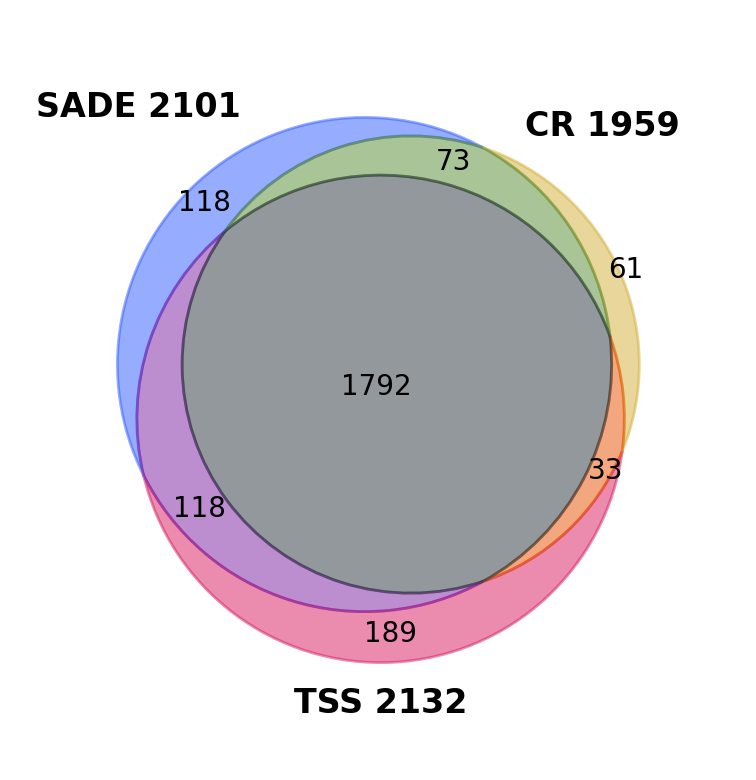

In [138]:
venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
)

fixed_sizes = (0.4, 0.3, 0.4, 0.3, 0.4, 0.2, 0.2) 

fig, ax = plt.subplots(figsize=(4, 4))
v = venn3(venn_sets, set_labels=[f'SADE {union_cell_info[union_cell_info["atac_pass_entropy"]].shape[0]}', 
                                 f'CR {union_cell_info[union_cell_info["atac_pass_CR"]].shape[0]}', 
                                 f'TSS {union_cell_info[union_cell_info["atac_pass_archr_TSS"]].shape[0]}'], 
                          layout_algorithm=DefaultLayoutAlgorithm(fixed_sizes),  # Use default layout for consistent circle positions
             ax=ax, )


v.get_patch_by_id('100').set_color('#2E5BFF') # Set A
v.get_patch_by_id('010').set_color('#D4AF37') # Set B
v.get_patch_by_id('001').set_color('#D81B60') # Set C

v.get_patch_by_id('110').set_color('#558B2F') # A & B (Green)
v.get_patch_by_id('011').set_color('#E65100') # B & C (Purple)
v.get_patch_by_id('101').set_color('#7B1FA2') # A & C (Orange)
v.get_patch_by_id('111').set_color('#263238') # Triple (Slate)

for patch in v.patches:
    if patch: # Some patches might be None if subsets are empty
        patch.set_alpha(.5)

# Change font size of subset counts
for text in v.subset_labels:
    if text: # Check if label exists
        text.set_fontsize(10)

# Change font size of Set Labels (A, B, C)
for text in v.set_labels:
    if text:
        text.set_fontsize(12)
        text.set_fontweight('bold')

for label in ['100', '010', '001', '110', '011', '101', '111']:
    vl = v.get_label_by_id(label)
    x, y = vl.get_position()
    if label in ['100',  '001', '010']:  # Single sets
        vl.set_position((x * 1.1, y * 1.05 ))
    elif label in ['110',  '101']:  # Double sets
        vl.set_position((x * 1.2, y * 1.1))
    elif label == '011':  # B & C
        vl.set_position((x * 1.1, y * 0.9))

fig.tight_layout()

# FRIP score

In [140]:
# Load fragments file
frag_file = os.path.join(entropy_dir, 'fragments.tsv')
frag = pd.read_csv(frag_file, sep='\t', index_col=3, header=None)
frag.index.name ='atac_barcodes'
frag.columns = ['chrom', 'start', 'end', 'support']
frag['atac_bc'] = frag.index.map(lambda x: x.split('-1')[0])


In [ ]:
frag_in_Raw_peak_file = os.path.join(Union_cell_subdir, 'Rawpeaks', 'frag_overlap/frag_in_peaks.tsv')
frag_in_raw_peaks = pd.read_csv(frag_in_Raw_peak_file, sep='\t', index_col=3, header=None)
frag_in_raw_peaks.index.name ='atac_barcodes'
frag_in_raw_peaks.columns = ['chrom', 'start', 'end', 'support']


In [ ]:
entropy_df['total_fragments'] = entropy_df.index.map(frag.groupby('atac_barcodes').size())
entropy_df['Nfrag_in_rawpeaks'] = entropy_df.index.map(frag_in_raw_peaks.groupby('atac_barcodes').size()).fillna(0).astype(int)
entropy_df['frip_rawpeaks'] = entropy_df['Nfrag_in_rawpeaks'] / entropy_df['total_fragments']

In [ ]:
rawpeaks_subdir = os.path.join(Union_cell_subdir, 'Rawpeaks')
frag_in_rawpeaks_file = os.path.join(rawpeaks_subdir, 'frag_overlap', 'frag_in_peaks.tsv')

col_names = ['chrom', 'start', 'end', 'atac_barcode', 'support']
frag_in_rawpeaks_df = pd.read_csv(frag_in_rawpeaks_file, sep='\t', names=col_names)
frag_in_rawpeaks_df['atac_bc'] = frag_in_rawpeaks_df['atac_barcode'].str.split('-').str[0]
print(frag_in_rawpeaks_df.head(2))


Nfrag_in_rawpeaks_per_bc = frag_in_rawpeaks_df.groupby('atac_bc').size()
union_cell_info['Nfrag_in_rawpeaks'] = union_cell_info.index.map(Nfrag_in_rawpeaks_per_bc).fillna(0).astype(int)
union_cell_info['frip_rawpeaks'] = union_cell_info['Nfrag_in_rawpeaks'] / union_cell_info['total_fragments']

-----   common]  [SADE unique]  [CR unique]  [TSS unique]  [SADE+CR, not TSS]  [SADE+TSS, not CR]  [CR+TSS, not SADE
mean 	 ['0.672  ', '0.368  ', '0.348  ', '0.043  ', '0.518  ', '0.646  ', '0.549  ']
median 	 ['0.683  ', '0.306  ', '0.413  ', '0.037  ', '0.656  ', '0.675  ', '0.573  ']


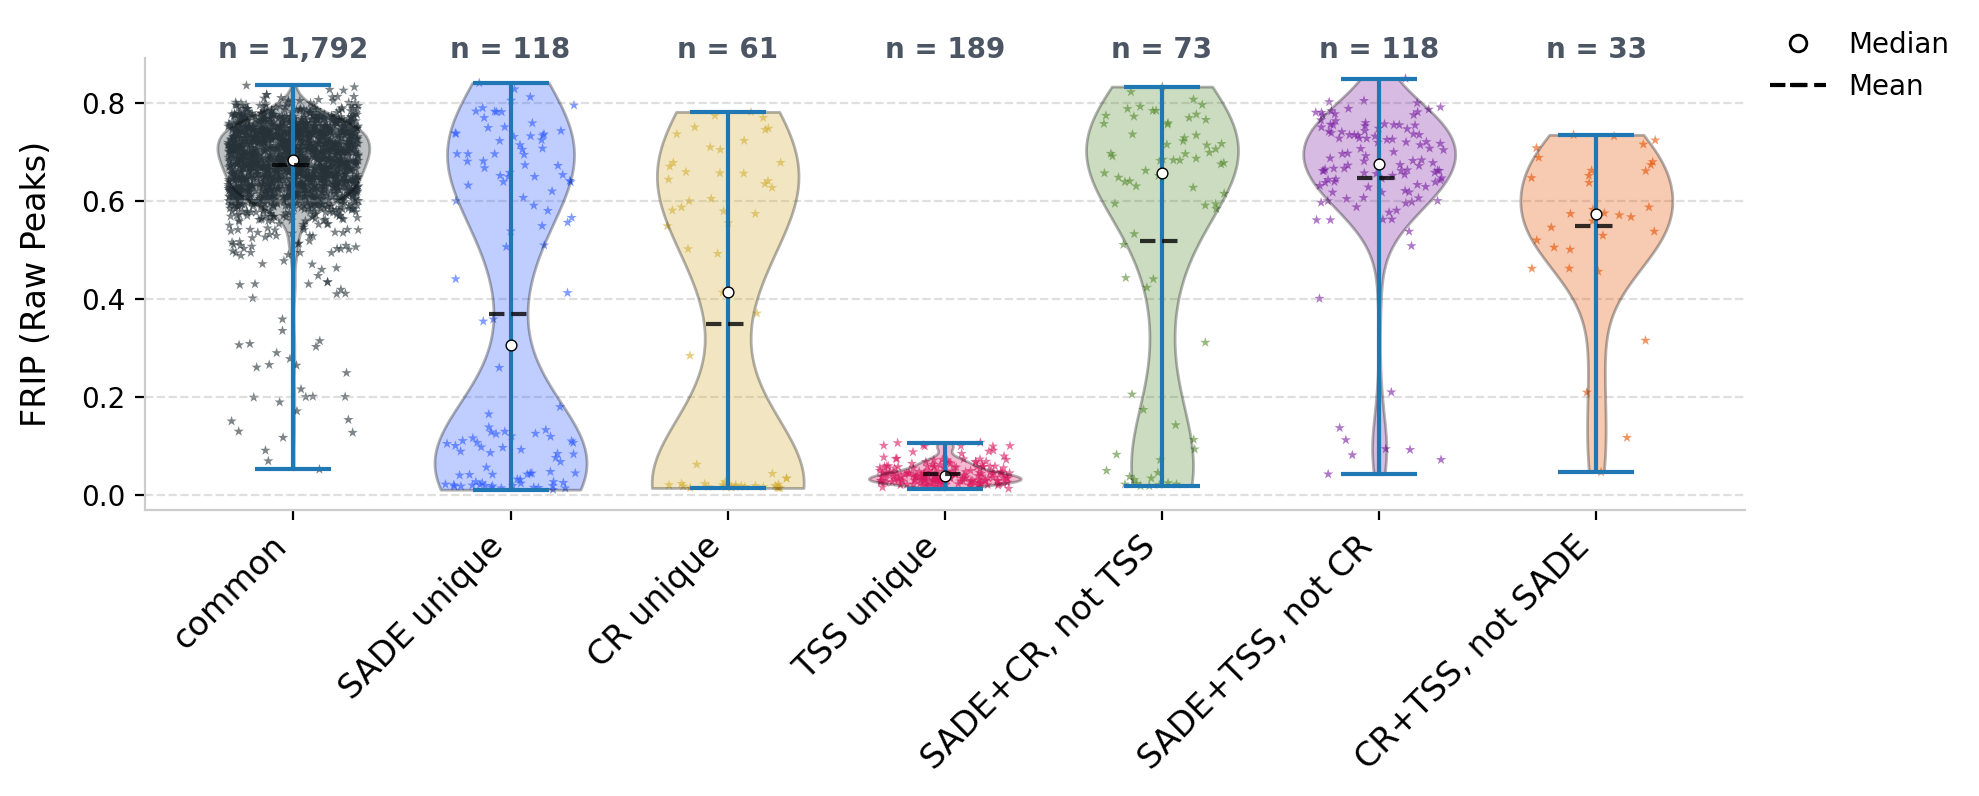

In [262]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, alpha=0.5, color='orange', marker='*', edgecolors='none', lw=1):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=alpha, s=15, zorder=1, marker=marker, lw=lw, edgecolors=edgecolors) # s controls point size

np.random.seed(999) # For reproducibility of jitter
fig, ax = plt.subplots( figsize=(10, 4))

width = 0.9

colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]


frip_values = [ union_cell_info['frip_rawpeaks'].loc[union_cell_info['_3set_identified_by_atac'] == cat] for 
               cat in unique_categories ]
x_positions = range(len(frip_values))

for i, group_data in enumerate(frip_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_list[i], alpha=0.6)

v1 = ax.violinplot( frip_values, 
              positions=x_positions, widths=0.7, 
              showmedians=False, showmeans=False)

total_counts = [ frip.shape[0] for frip in frip_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            fontsize=10, color='#4B5563', fontweight='bold')

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_list[i])
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(frip_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1.5, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels(unique_categories, fontsize=12, fontweight='medium', rotation=45, ha='right')
ax.set_ylabel('FRIP (Raw Peaks)', fontsize=12, labelpad=10)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
ax.legend(handles=legend_elements, loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(1, 0.85))

fig.tight_layout()

mean_frip_values = [f'{np.mean(a):.3f}  ' for a in frip_values]
median_frip_values = [f'{np.median(a):.3f}  ' for a in frip_values]
print('-----   ' + ']  ['.join(labels_map))
print(f'mean \t {mean_frip_values}')
print(f'median \t {median_frip_values}')

# P(closed-state)

In [183]:
union_cell_info['P_closed_state'] = union_cell_info.index.map(lambda x: entropy_df.set_index('atac_bc').loc[x, 'P_closed_state'] if x in entropy_df['atac_bc'].values else np.nan)

-----   common]  [SADE unique]  [CR unique]  [TSS unique]  [SADE+CR, not TSS]  [SADE+TSS, not CR]  [CR+TSS, not SADE
mean 	 ['0.027  ', '0.022  ', '0.333  ', '0.001  ', '0.060  ', '0.030  ', '0.005  ']
median 	 ['0.025  ', '0.013  ', 'nan  ', 'nan  ', '0.014  ', '0.022  ', 'nan  ']


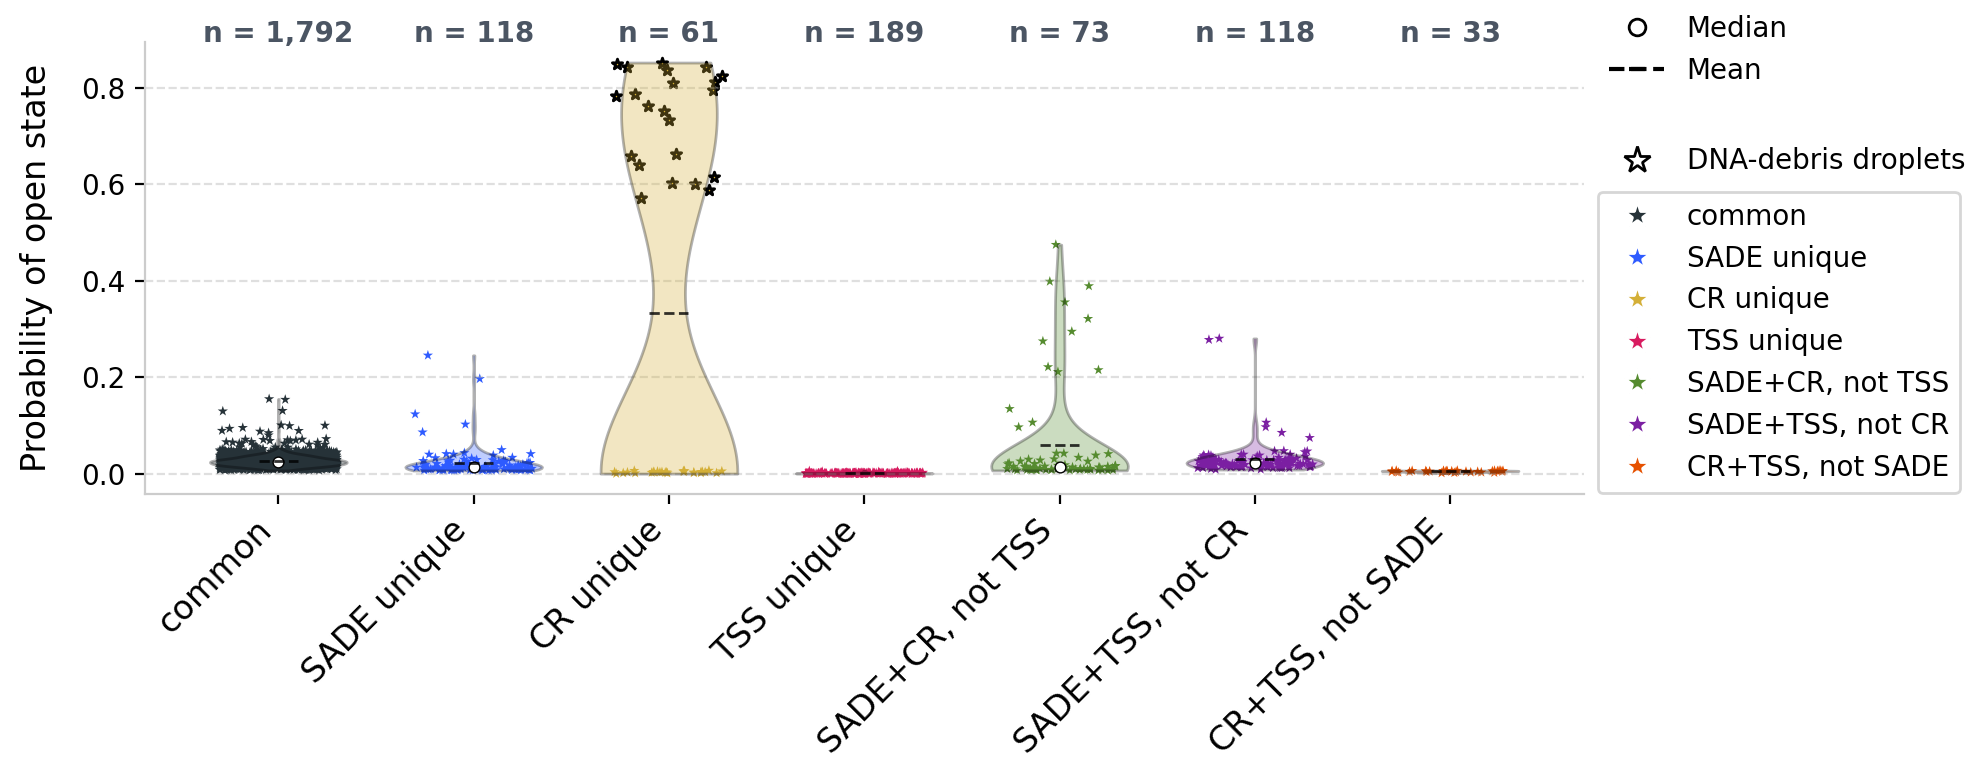

In [256]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange', marker='*', edgecolors='black', lw=1):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=1, s=15, zorder=1, marker=marker, lw=lw, edgecolors=edgecolors) # s controls point size

colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100'] 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]


np.random.seed(999) # For reproducibility of jitter
fig, ax = plt.subplots(ncols=1, figsize=(10, 4))
width = 0.9

p_closed_state_values = [ 1 - union_cell_info.loc[union_cell_info['_3set_identified_by_atac'] == cat, 'P_closed_state'] for 
               cat in unique_categories ]
DNA_debris_flag = [ union_cell_info['DNA_debris'].loc[(union_cell_info['_3set_identified_by_atac'] == cat) ] for 
                cat in unique_categories ]

x_positions = range(len(p_closed_state_values))

for i, group_data in enumerate(p_closed_state_values):
    # For non-DNA-debris cells, add jittered points
    add_jittered_points(ax, group_data[DNA_debris_flag[i] == 'NO'], x_positions[i], color=colors_list[i], edgecolors='none',)
    # For DNA-debris droplets 
    add_jittered_points(ax, group_data[DNA_debris_flag[i] == 'YES'], x_positions[i], color=colors_list[i], edgecolors='black')

v1 = ax.violinplot( [v.dropna() for v in p_closed_state_values], positions=x_positions, widths=0.7, 
              showmedians=False, showmeans=False, showextrema=False)

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_list[i])
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

for i, group_data in enumerate(p_closed_state_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

total_counts = [ p_closed_state.shape[0] for p_closed_state in p_closed_state_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] , f'n = {count:,}', ha='center', 
            fontsize=10, color='#4B5563', fontweight='bold')

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels(unique_categories, fontsize=12, fontweight='medium', rotation=45, ha='right')
ax.set_ylabel('Probability of open state', fontsize=12, labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
leg1 = ax.legend(handles=legend_elements, loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(1, 0.85))
ax.add_artist(leg1)  # Add the first legend back to the axes so that it doesn't get overwritten by the second legend

droplet_handles = [Line2D([0], [0], marker='*', color='w',  markeredgecolor='black', markerfacecolor='none', label='DNA-debris droplets', markersize=10),
                  ]
#ax.legend(handles=droplet_handles, loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(1, 0.65) )
leg2 = ax.legend(handles=droplet_handles, loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(1, 0.65) )
ax.add_artist(leg2)  # Add the second legend back to the axes

ax.legend(handles=[Line2D([0], [0], marker='*', color='w', label=labels_map[c],
                          markerfacecolor=colors_map[c], markersize=10) for c in colors_map.keys()],
             bbox_to_anchor=(1, 0.7), loc='upper left', ncol=1, fontsize=10)


fig.tight_layout()

mean_p_closed_state_values = [f'{np.mean(a):.3f}  ' for a in p_closed_state_values]
median_p_closed_state_values = [f'{np.median(a):.3f}  ' for a in p_closed_state_values]
print('-----   ' + ']  ['.join(labels_map))
print(f'mean \t {mean_p_closed_state_values}')
print(f'median \t {median_p_closed_state_values}')

# TSSe score from SNAPATAC (not from ArchR)

In [149]:
import snapatac2 as snap

/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [150]:
data = snap.pp.import_fragments(
    frag_file,
    chrom_sizes=snap.genome.hg38,
    sorted_by_barcode=False,
)

snap.metrics.tsse(data, snap.genome.hg38)

In [162]:
union_cell_info['atac_barcodes'] = union_cell_info.index + '-1'
union_cell_info['tsse_score'] = union_cell_info['atac_barcodes'].map(lambda x: data.obs.loc[x, 'tsse'])

In [163]:
union_cell_info.head(2)

,total_fragments,atac_pass_CR,atac_pass_entropy,atac_pass_archr_TSS,_2set_identified_by_atac_SC,_2set_identified_by_atac_ST,rna_barcodes,rna_pass_CR,Entropy,leiden_RNA_scVI,DNA_debris,_3set_identified_by_atac,Nfrag_in_rawpeaks,frip_rawpeaks,atac_barcodes,tsse_score
atac_bc,,,,,,,,,,,,,,,,
AAACAAGCAAGTTAGT,2412,True,True,True,both,both,GGCTAGTGTGTTAGCA,True,0.218328,3,NO,common,1729,0.716833,AAACAAGCAAGTTAGT-1,37.408568
AAACAAGCATTTCTTC,9030,True,True,True,both,both,GGCTAGTGTACGTTTC,True,0.074451,0,NO,common,1538,0.170321,AAACAAGCATTTCTTC-1,11.363636


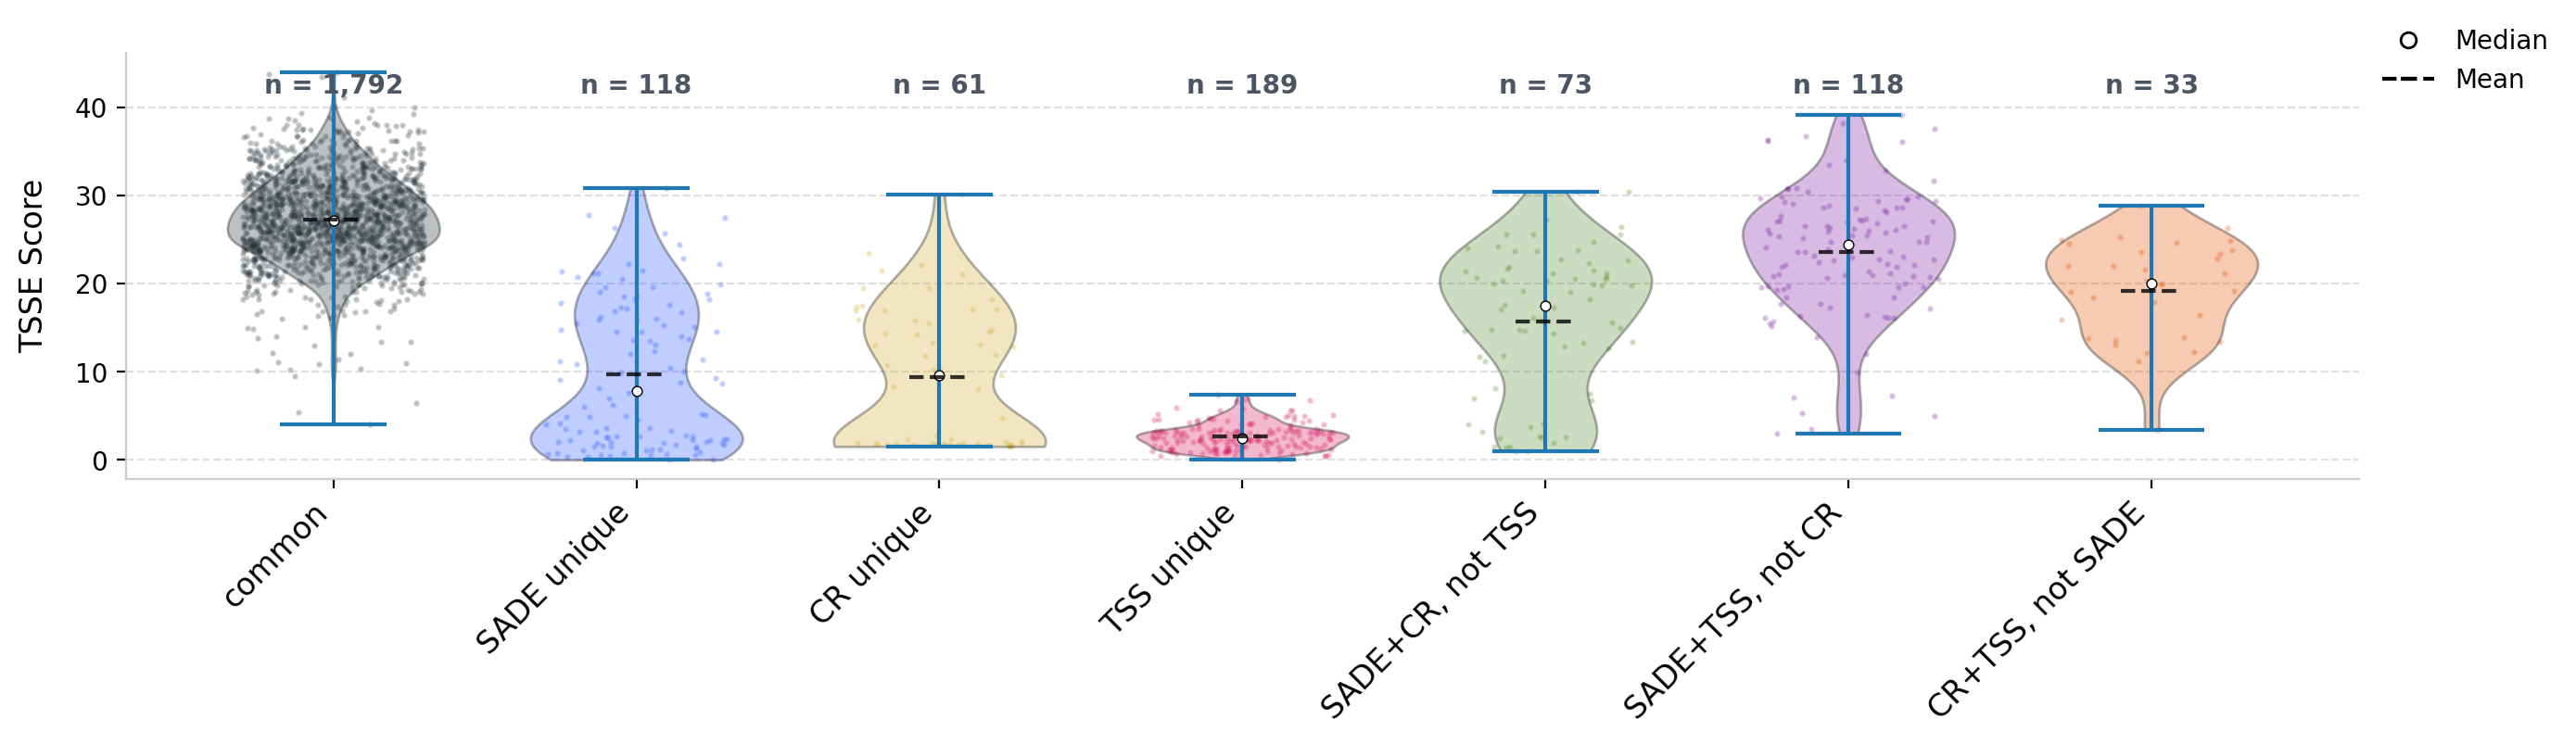

-----   common]  [SADE+CR, not TSS]  [SADE+TSS, not CR]  [TSS unique]  [CR+TSS, not SADE]  [SADE unique]  [CR unique
mean 	 ['27.294  ', '9.699  ', '9.363  ', '2.625  ', '15.699  ', '23.613  ', '19.196  ']
median 	 ['27.168  ', '7.828  ', '9.553  ', '2.457  ', '17.455  ', '24.401  ', '20.034  ']


In [164]:
def add_jittered_points(ax, data_group, position, jitter_width=0.3, color='orange'):
    # Generate random horizontal jitter
    x_jittered = position + np.random.uniform(-jitter_width, jitter_width, size=len(data_group))
    ax.scatter(x_jittered, data_group, color=color, alpha=0.2, s=2, zorder=1) # s controls point size

np.random.seed(999) # For reproducibility of jitter
fig, ax = plt.subplots(ncols=1, figsize=(14, 4))

width = 0.9

colors_list = [ '#263238','#2E5BFF', "#D4AF37", '#D81B60', '#558B2F', '#7B1FA2', '#E65100']  # ,   '#94A3B8' 
unique_categories = ['common',  'SADE unique', 'CR unique', 'TSS unique',  'SADE+CR, not TSS', 'SADE+TSS, not CR', 'CR+TSS, not SADE', ]


tsse_values = [ union_cell_info['tsse_score'].loc[union_cell_info['_3set_identified_by_atac'] == cat] for 
               cat in unique_categories ]
x_positions = range(len(tsse_values))

for i, group_data in enumerate(tsse_values):
    add_jittered_points(ax, group_data, x_positions[i], color=colors_list[i])

v1 = ax.violinplot( tsse_values, 
              positions=x_positions, widths=0.7, 
              showmedians=False, showmeans=False)

total_counts = [ tsse.shape[0] for tsse in tsse_values ]
for i, count in enumerate(total_counts):
    ax.text(x_positions[i], ax.get_ylim()[1] * 0.9, f'n = {count:,}', ha='center', 
            fontsize=10, color='#4B5563', fontweight='bold')

for i, body in enumerate(v1['bodies']):
    body.set_facecolor(colors_list[i])
    body.set_edgecolor('black')
    body.set_alpha(0.3)
    body.set_zorder(2)

# 4. Add "Inner Boxplot" elements for a premium look
for i, group_data in enumerate(tsse_values):
    quartile1, median, quartile3 = np.percentile(group_data, [25, 50, 75])
    mean = np.mean(group_data)
    # Draw a thin line for the mean
    ax.hlines(mean, x_positions[i] - 0.1, x_positions[i] + 0.1, color='black', linestyle='--', lw=1.5, alpha=0.8, zorder=4)
    ax.scatter(x_positions[i], median, color='white', s=15, zorder=3, edgecolor='black', lw=0.5)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_xticks(x_positions)
ax.set_xticklabels(unique_categories, fontsize=12, fontweight='medium', rotation=45, ha='right')
ax.set_ylabel('TSSE Score', fontsize=12, labelpad=10)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Median', markerfacecolor='white', markeredgecolor='black', markersize=6),
    Line2D([0], [0], marker='_', color='black', label='Mean', markersize=6, markeredgewidth=1.5, linestyle='--'),
]
ax.legend(handles=legend_elements, loc='lower left', frameon=False, fontsize=10, bbox_to_anchor=(1, 0.85))

plt.tight_layout()
plt.show()


mean_tsse_values = [f'{np.mean(a):.3f}  ' for a in tsse_values]
median_tsse_values = [f'{np.median(a):.3f}  ' for a in tsse_values]
print('-----   ' + ']  ['.join(labels_map))
print(f'mean \t {mean_tsse_values}')
print(f'median \t {median_tsse_values}')

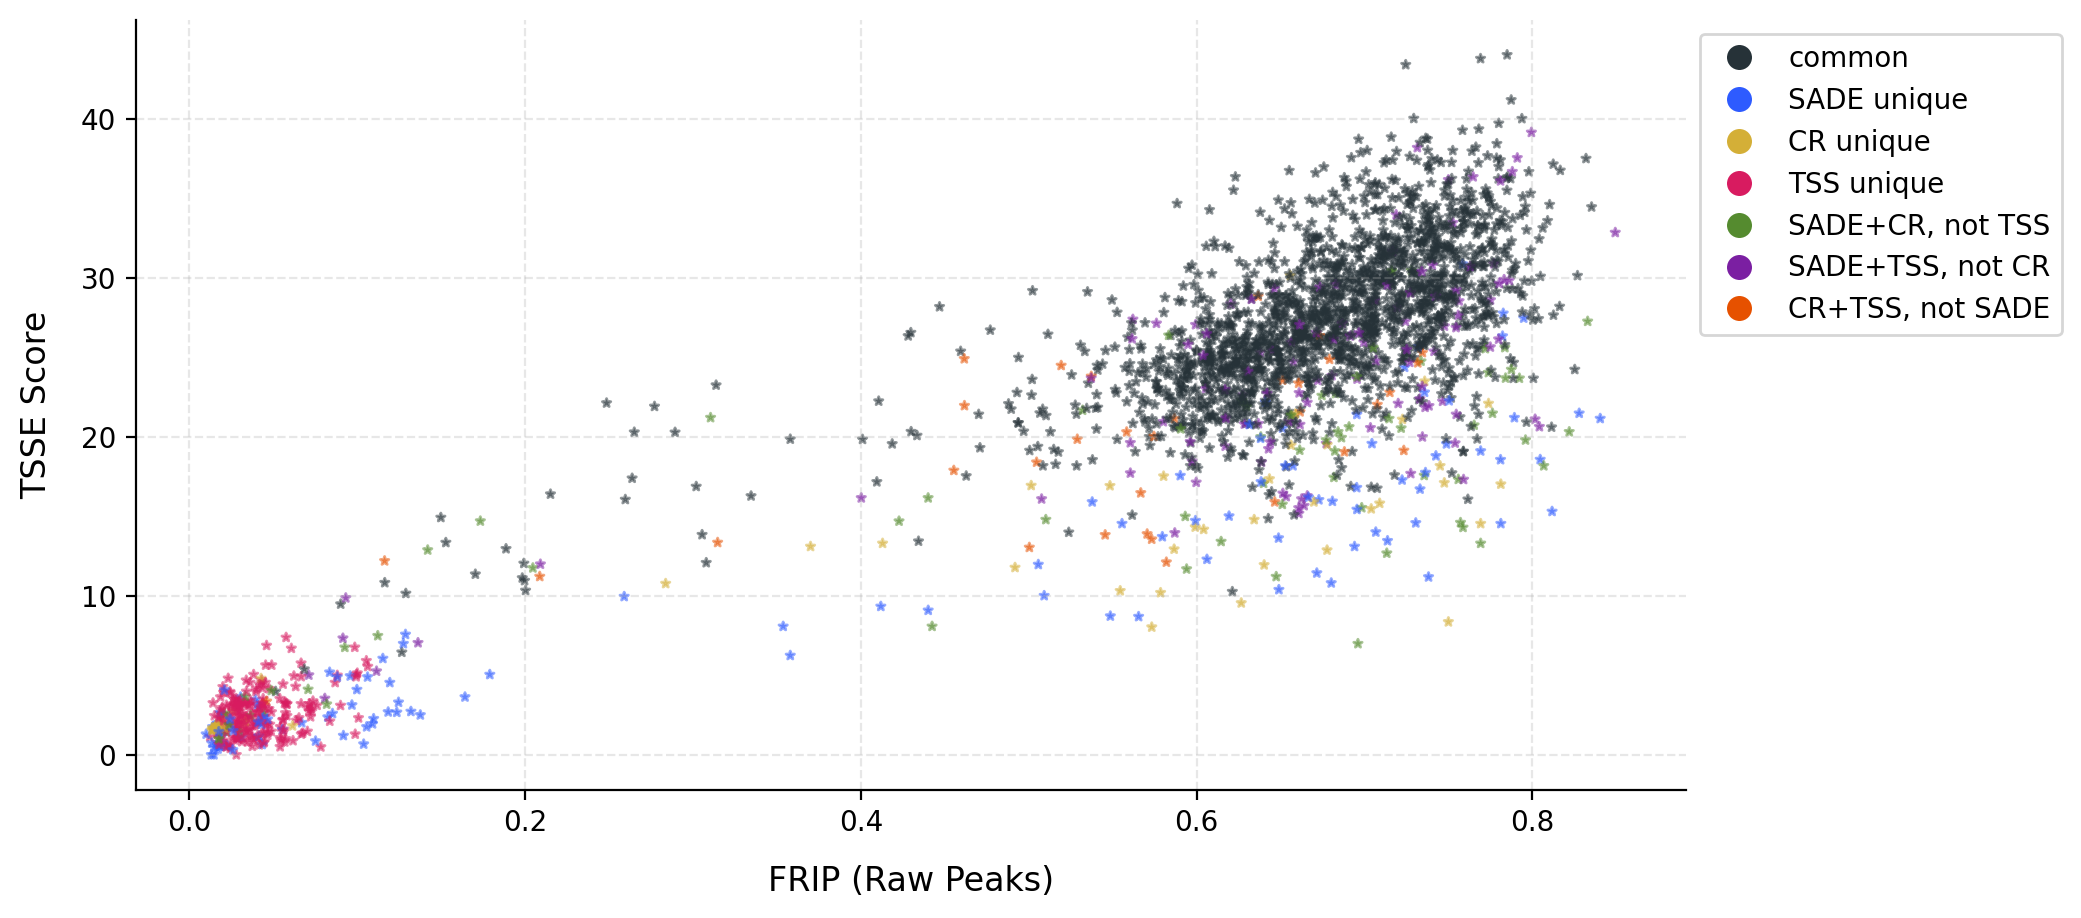

In [170]:
fig, ax = plt.subplots( figsize=(10, 5))
_ = ax.scatter(
    union_cell_info['frip_rawpeaks'],
    union_cell_info['tsse_score'],
    c=union_cell_info['_3set_identified_by_atac'].map(colors_map), 
    alpha=0.5,
    s=10, 
    lw=1, 
    marker='*',)
ax.set_xlabel('FRIP (Raw Peaks)', fontsize=12, labelpad=10)
ax.set_ylabel('TSSE Score', fontsize=12, labelpad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]

ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label=labels_map[c],
                          markerfacecolor=colors_map[c], markersize=10) for c in colors_map.keys()],
             bbox_to_anchor=(1, 1), loc='upper left', ncol=1, fontsize=10)



## Just ATAC nuclei-calling comparison

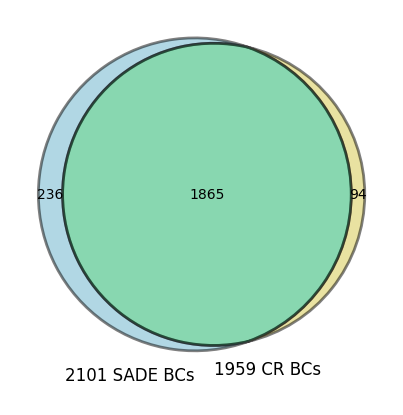

In [13]:
venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    )

fig1, ax1 = plt.subplots()

vennfig = venn2(
    venn_sets[:2], 
                set_labels = (f'{len(venn_sets[0])} SADE BCs\n',f'{len(venn_sets[1])} CR BCs\n'), 
                set_colors = ( 'blue', 'orange'), 
                ax = ax1)


set_colors = ("#64B1CB", "#D4C645", "#13B062")  
for idx, color in zip(('10', '01', '11'), set_colors):
    patch = vennfig.get_patch_by_id(idx)
    patch.set_color(color)
    patch.set_alpha(0.5)  # Set transparency for blending
    patch.set_edgecolor('black')  # Set edge color to black
    patch.set_linewidth(2)  # Set edge line width

# plt.title('SADE vs CR', fontsize=16)


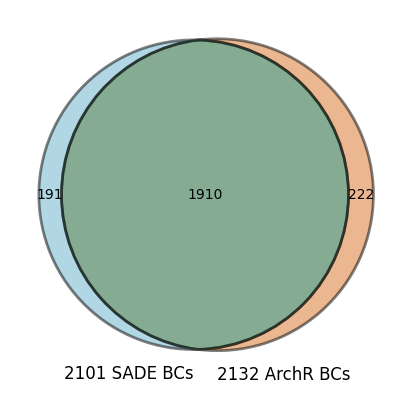

In [15]:
venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
    )

set_colors = ('#ADD8E6', '#FFFFE0', '#FFB6C1') 


fig1, ax1 = plt.subplots()

vennfig = venn2(
    venn_sets[:2], 
                set_labels = (f'{len(venn_sets[0])} SADE BCs\n',f'{len(venn_sets[1])} ArchR BCs\n'), 
                ax = ax1)


set_colors = ("#64B1CB", "#D67022", "#0C5B28")  
for idx, color in zip(('10', '01', '11'), set_colors):
    patch = vennfig.get_patch_by_id(idx)
    patch.set_color(color)
    patch.set_alpha(0.5)  # Set transparency for blending
    patch.set_edgecolor('black')  # Set edge color to black
    patch.set_linewidth(2)  # Set edge line width

# plt.title('SADE vs ArchR', fontsize=16)


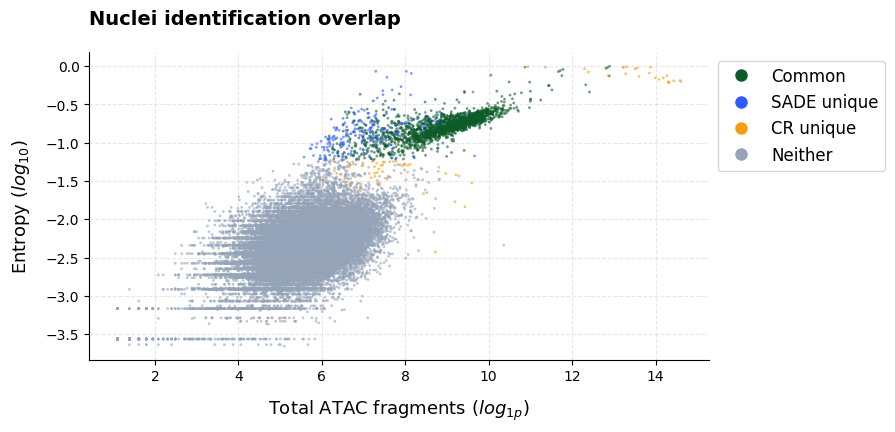

In [ ]:
fig, ax = plt.subplots( figsize=(8, 4) )


colors_map = {'both':'#0C5B28', 'entropy_only':'#2E5BFF', 'cr_only':'#F59E0B', 'none':'#94A3B8'}
labels_map = {'both':'Common', 'entropy_only':'SADE unique', 'cr_only':'CR unique', 'none':'Neither'}
ax.scatter( np.log1p(total_frag_per_bc['total_fragments']), np.log10(total_frag_per_bc['Entropy'] ),  
            c= total_frag_per_bc['_2set_identified_by_atac_SC'].map(colors_map),
            alpha=0.6, 
                s=4,          
                lw=0,         
                rasterized=True # Keeps the file size light if saving to PDF
                        )

# 4. Clean up the Aesthetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total ATAC fragments ($log_{1p}$)', fontsize=13, labelpad=10)
ax.set_ylabel('Entropy ($log_{10}$)', fontsize=13, labelpad=10)
ax.set_title('Nuclei identification overlap', fontsize=14, loc='left', fontweight='bold', pad=20)

handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]
ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label=labels_map[c],
                          markerfacecolor=colors_map[c], markersize=10) for c in colors_map.keys()],
             bbox_to_anchor=(1, 1), loc='upper left', ncol=1, fontsize=12)

plt.show()

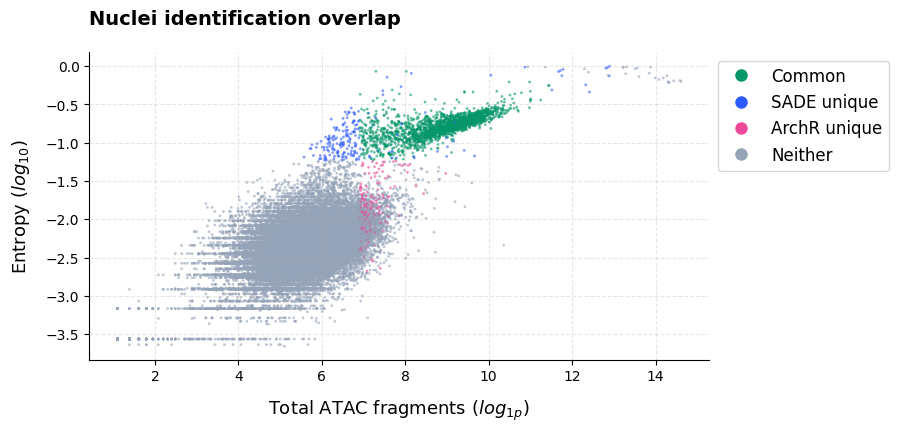

In [35]:
fig, ax = plt.subplots( figsize=(8, 4) )

colors_map = {'both':"#059669", 'entropy_only':'#2E5BFF', 'tss_only':"#EC4899", 'none':'#94A3B8'}
labels_map = {'both':'Common', 'entropy_only':'SADE unique', 'tss_only':'ArchR unique', 'none':'Neither'}
ax.scatter( np.log1p(total_frag_per_bc['total_fragments']), np.log10(total_frag_per_bc['Entropy']),  c= total_frag_per_bc['_2set_identified_by_atac_ST'].map(colors_map), 
            alpha=0.6, 
            s=4,          
            lw=0,         
            rasterized=True # Keeps the file size light if saving to PDF
                )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xlabel('Total ATAC fragments ($log_{1p}$)', fontsize=13, labelpad=10)
ax.set_ylabel('Entropy ($log_{10}$)', fontsize=13, labelpad=10)
ax.set_title('Nuclei identification overlap', fontsize=14, loc='left', fontweight='bold', pad=20)


handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors_map.items()]

ax.legend(handles=[Line2D([0], [0], marker='o', color='w', label=labels_map[c],
                          markerfacecolor=colors_map[c], markersize=10) for c in colors_map.keys()],
             bbox_to_anchor=(1, 1), loc='upper left', ncol=1, fontsize=12)


plt.show()

## With RNA info

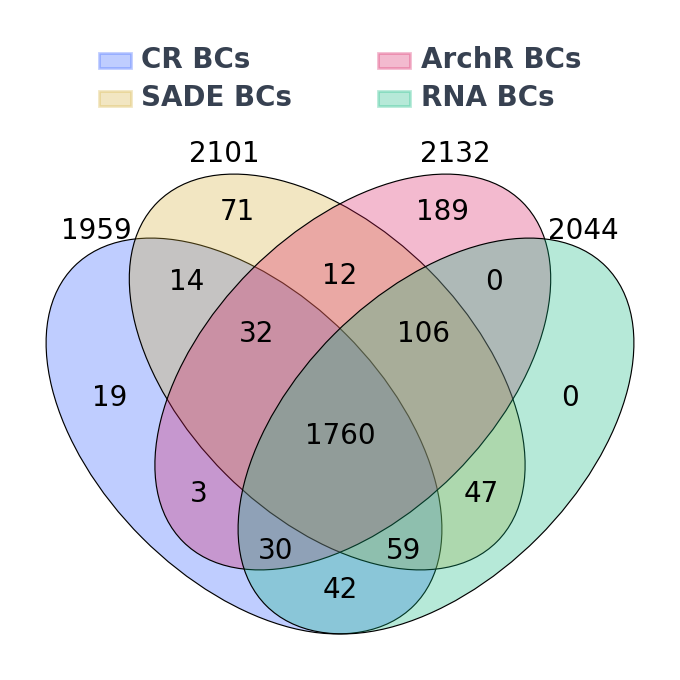

In [ ]:
from venny4py.venny4py import *




venn_4sets = {
    'CR BCs': set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    'SADE BCs':  set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    'ArchR BCs': set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
    'RNA BCs': set(union_cell_info.loc[union_cell_info['rna_pass_CR']].index) }

fig = venny4py(sets=venn_4sets, colors=['#2E5BFF', "#D4AF37", '#D81B60', '#10B981'])
ax = plt.gca()

# Make the circles look soft and premium
for patch in ax.get_children():
    if isinstance(patch, plt.Circle) or 'PathPatch' in str(type(patch)):
        patch.set_alpha(0.6)       # Soften the overlap
        patch.set_edgecolor('white') # White borders make colors "pop"
        patch.set_linewidth(1.5)

# Improve text readability
for text in ax.findobj(plt.Text):
    text.set_fontsize(10)
    # Highlight the set labels (usually the ones with 'BCs')
    if 'BCs' in text.get_text():
        text.set_fontweight('bold')
        text.set_fontsize(10)
        text.set_color('#374151') # Deep charcoal instead of pure black


ax.axis('off')

plt.tight_layout()
plt.show()

In [83]:
rna_info_file = os.path.join(Union_cell_subdir, 'Union_3set_rna_info.tsv')
union_cell_rna_info = pd.read_csv(rna_info_file, sep='\t', index_col=1)
union_cell_rna_info.head(2)

,rna_barcodes,rna_pass_CR,leiden_RNA_scVI,total_RNA_UMI,total_RNA_UMI_log,n_genes_by_RNA_counts,N_MT_counts,MT%
atac_barcodes,,,,,,,,
ACAGCGGGTTTGTAGC,AAACAGCCAGGCTACT,True,1,3931.0,8.276903,1772,519.0,13.202747
CATTTAGGTAACAGCA,AAACATGCAAGGATTA,True,3,3566.0,8.179481,1689,401.0,11.245092


In [85]:
col_list = ['total_RNA_UMI', 'total_RNA_UMI_log', 'n_genes_by_RNA_counts', 'N_MT_counts', 'MT%']
for col in col_list:
    union_cell_info[col] = union_cell_info.index.map(union_cell_rna_info[col])

Text(0, 0.5, 'Total RNA UMI ($log_{1p}$)')

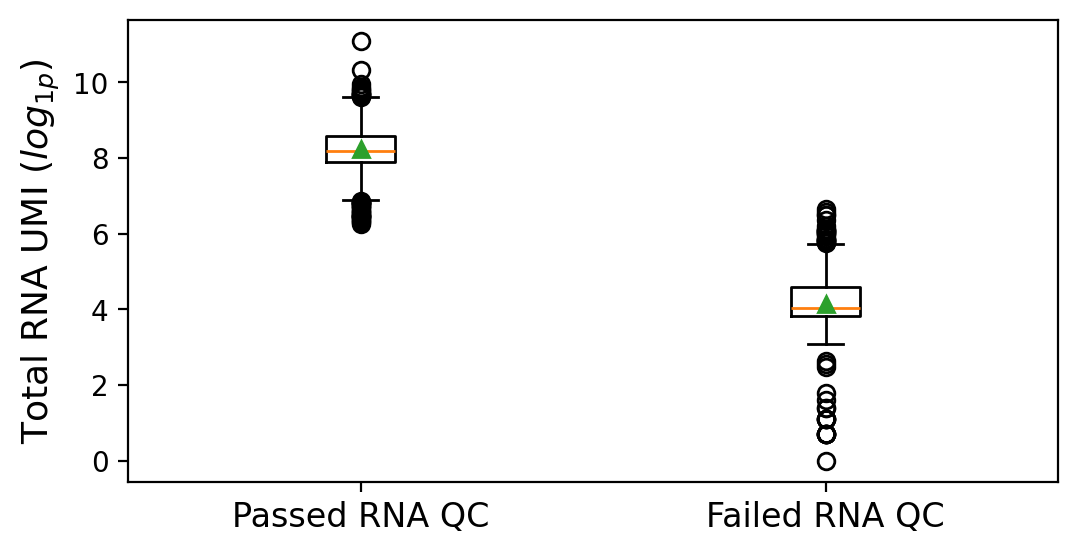

In [96]:
fig, ax = plt.subplots( figsize=(6, 3) )

rna_umi = [union_cell_info.loc[union_cell_info['rna_pass_CR'], 'total_RNA_UMI'],
           union_cell_info.loc[~union_cell_info['rna_pass_CR'], 'total_RNA_UMI'].dropna(),
]
rna_umi = [np.log1p(x) for x in rna_umi]

x_pos = range(len(rna_umi))
ax.boxplot(rna_umi, positions=x_pos, showmeans=True)
ax.set_xticks(x_pos)
ax.set_xticklabels(['Passed RNA QC', 'Failed RNA QC'], fontsize=12)
ax.set_ylabel('Total RNA UMI ($log_{1p}$)', fontsize=13)

In [41]:
union_cell_info.loc[union_cell_info['rna_pass_CR']].groupby('atac_pass_CR').size()

atac_pass_CR
False     153
True     1891
dtype: int64

In [42]:
union_cell_info.loc[union_cell_info['rna_pass_CR']].groupby('atac_pass_entropy').size()

atac_pass_entropy
False      72
True     1972
dtype: int64

In [44]:
union_cell_info.loc[union_cell_info['rna_pass_CR']].groupby('atac_pass_archr_TSS').size()

atac_pass_archr_TSS
False     148
True     1896
dtype: int64

In [48]:
1972 / 2044, 1896 / 2044, 1891 / 2044

(0.9647749510763209, 0.9275929549902152, 0.925146771037182)

In [46]:
union_cell_info['rna_pass_CR'].sum()

np.int64(2044)

### --

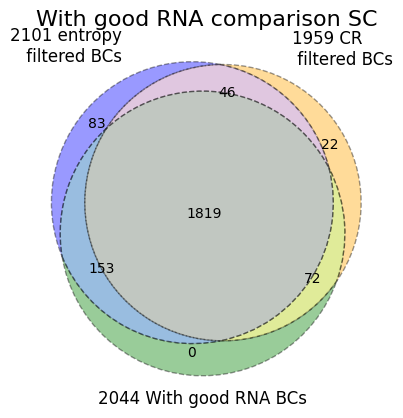

In [27]:

venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_CR']].index),
    set(union_cell_info.loc[union_cell_info['rna_pass_CR']].index)   
)
fixed_sizes = (0.2, 0.2, 0.15, 0.3, 0.2, 0.1, 2) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\n filtered BCs',f'{len(venn_sets[1])} CR \n filtered BCs', f'{len(venn_sets[2])} With good RNA BCs'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'green'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')


plt.title('With good RNA comparison SC', fontsize=16)
plt.show()

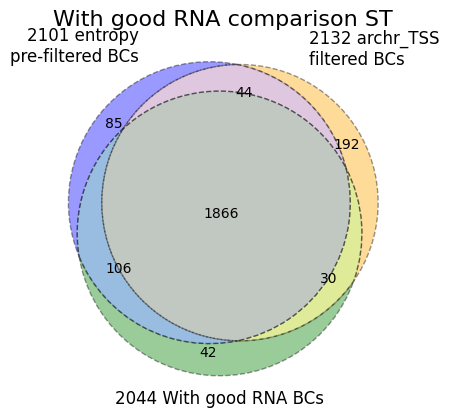

In [17]:

venn_sets = (
    set(union_cell_info.loc[union_cell_info['atac_pass_entropy']].index),
    set(union_cell_info.loc[union_cell_info['atac_pass_archr_TSS']].index),
    set(union_cell_info.loc[union_cell_info['rna_pass_CR']].index)   
)
fixed_sizes = (0.2, 0.2, 0.15, 0.3, 0.2, 0.1, 2) 

# alg = cost_based.LayoutAlgorithm(cost_fn=cost_based.pairwise_cost)
vennfig = venn3(venn_sets, set_labels = (f'{len(venn_sets[0])} entropy\npre-filtered BCs',f'{len(venn_sets[1])} archr_TSS \nfiltered BCs', f'{len(venn_sets[2])} With good RNA BCs'), 
                layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=fixed_sizes), 
                set_colors = ( 'blue', 'orange', 'green'))
for id in ['100', '010', '001', '110', '101', '011', '111']:
    vennfig.get_patch_by_id(id).set_edgecolor('black')
    vennfig.get_patch_by_id(id).set_linestyle('dashed')


plt.title('With good RNA comparison ST', fontsize=16)
plt.show()